In [1]:
from neuron import h, gui
import matplotlib.pyplot as plt

h.load_file("stdrun.hoc")
h.load_file("import3d.hoc")

class Cell:
    def __init__(self, swc_file):
        swc = h.Import3d_SWC_read()
        swc.input(swc_file)

        i3d = h.Import3d_GUI(swc, 0)

        # 👇 关键：把 section 挂到 self 上
        i3d.instantiate(self)

    def __repr__(self):
        return "Cell"

# 创建 cell
cell = Cell("../../data/morphology/example_tree.swc")

for sec in h.allsec():
    print(f"{sec.name()}'s parent seg is {sec.parentseg()}")

    n3d = int(h.n3d(sec=sec))
    print(f"n3d = {n3d}")

    for i in range(n3d):
        x = h.x3d(i, sec=sec)
        y = h.y3d(i, sec=sec)
        z = h.z3d(i, sec=sec)
        diam = h.diam3d(i, sec=sec)
        r = diam / 2

        print(f"  pt3d[{i}]: x={x:.3f}, y={y:.3f}, z={z:.3f}, r={r:.3f}")

--No graphics will be displayed.


Cell.soma[0]'s parent seg is None
n3d = 2
  pt3d[0]: x=0.000, y=-5.000, z=0.000, r=5.000
  pt3d[1]: x=0.000, y=5.000, z=0.000, r=5.000
Cell.axon[0]'s parent seg is Cell.soma[0](0)
n3d = 3
  pt3d[0]: x=0.000, y=-5.000, z=0.000, r=1.000
  pt3d[1]: x=5.000, y=-20.000, z=20.000, r=1.000
  pt3d[2]: x=12.000, y=-20.000, z=22.000, r=1.000
Cell.axon[1]'s parent seg is Cell.axon[0](0)
n3d = 2
  pt3d[0]: x=5.000, y=-20.000, z=20.000, r=1.000
  pt3d[1]: x=0.000, y=-30.000, z=30.000, r=0.800
Cell.dend[0]'s parent seg is Cell.soma[0](1)
n3d = 4
  pt3d[0]: x=0.000, y=5.000, z=0.000, r=1.800
  pt3d[1]: x=0.000, y=20.000, z=0.000, r=1.800
  pt3d[2]: x=-5.000, y=40.000, z=10.000, r=1.400
  pt3d[3]: x=-5.000, y=55.000, z=10.000, r=1.200
Cell.dend[1]'s parent seg is Cell.dend[0](1)
n3d = 3
  pt3d[0]: x=-5.000, y=55.000, z=10.000, r=1.200
  pt3d[1]: x=-5.000, y=60.000, z=20.000, r=1.000
  pt3d[2]: x=0.000, y=70.000, z=30.000, r=1.000
Cell.dend[2]'s parent seg is Cell.dend[0](1)
n3d = 2
  pt3d[0]: x=-5.000

In [5]:
cell.soma[0].psection()

{'point_processes': {'IClamp': {IClamp[0]}},
 'density_mechs': {'hh': {'gnabar': [0.12],
   'gkbar': [0.036],
   'gl': [0.0003],
   'el': [-54.3],
   'gna': [1.0690178613674613e-05],
   'gk': [0.0003684842992417191],
   'il': [-0.003202253506342906],
   'minf': [0.05309386437793888],
   'hinf': [0.5952174200816258],
   'ninf': [0.3180726884571195],
   'mtau': [0.2370663714365256],
   'htau': [8.514091337177376],
   'ntau': [5.457179630948428],
   'm': [0.05309386065017939],
   'h': [0.595210827532068],
   'n': [0.31807468752734763]}},
 'ions': {'na': {'ena': [50.0],
   'nai': [10.0],
   'nao': [140.0],
   'ina': [-0.0012290945025698336],
   'dina_dv_': [1.0690178613636733e-05]},
  'k': {'ek': [-77.0],
   'ki': [54.4],
   'ko': [2.5],
   'ik': [0.004431326461856679],
   'dik_dv_': [0.0003684842992436599]}},
 'morphology': {'L': 10.0,
  'diam': [10.0],
  'pts3d': [(0.0, -5.0, 0.0, 10.0), (0.0, 5.0, 0.0, 10.0)],
  'parent': None,
  'trueparent': None},
 'nseg': 1,
 'Ra': 35.4,
 'cm': [1.0

In [2]:
for sec in cell.soma:
    sec.insert("hh")

stim = h.IClamp(cell.soma[0](0.5))
stim.delay = 100
stim.dur = 500
stim.amp = 0.1  # nA

t = h.Vector().record(h._ref_t)

# 电压
v = h.Vector().record(cell.soma[0](0.5)._ref_v)

# gating variables（来自 hh）
m = h.Vector().record(cell.soma[0](0.5)._ref_m_hh)
h_var = h.Vector().record(cell.soma[0](0.5)._ref_h_hh)
n = h.Vector().record(cell.soma[0](0.5)._ref_n_hh)

# 离子浓度
nai = h.Vector().record(cell.soma[0](0.5)._ref_nai)
ki = h.Vector().record(cell.soma[0](0.5)._ref_ki)

# 平衡电位
ena = h.Vector().record(cell.soma[0](0.5)._ref_ena)
ek = h.Vector().record(cell.soma[0](0.5)._ref_ek)

h.tstop = 700
h.v_init = -65

h.run()

0.0

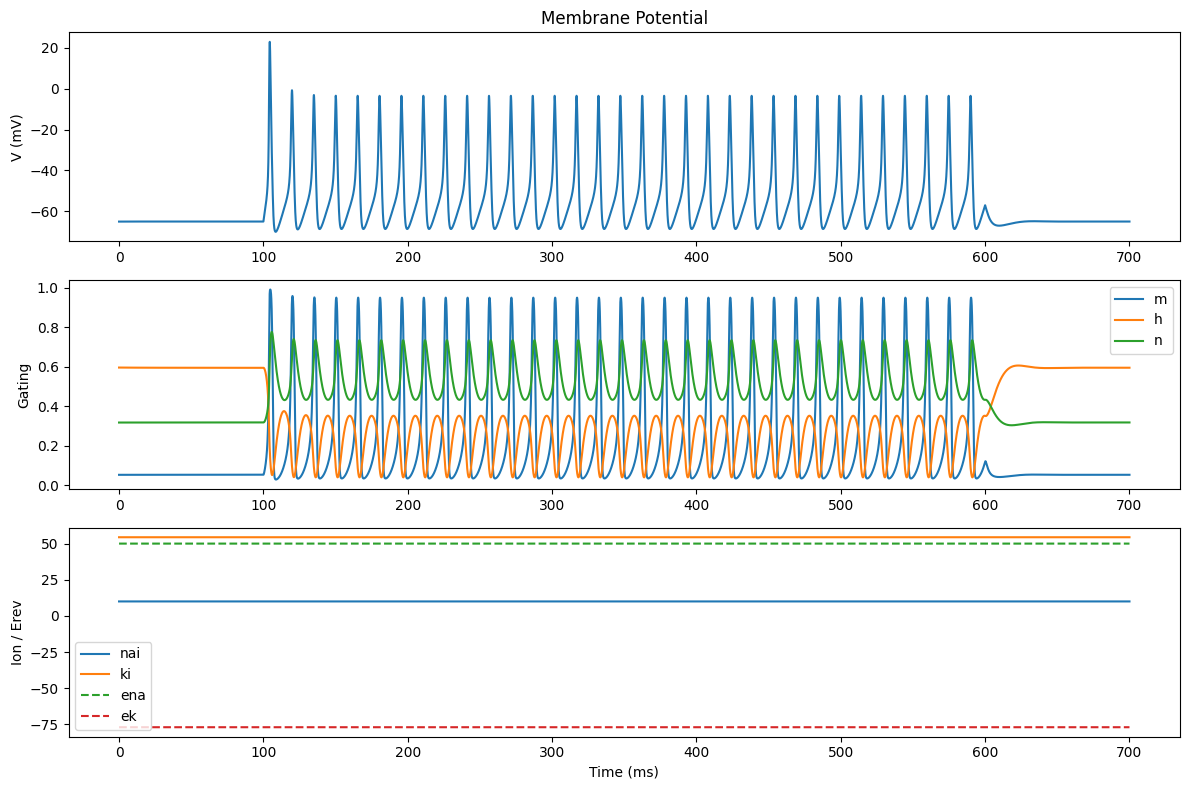

In [3]:
plt.figure(figsize=(12, 8))

# 电压
plt.subplot(3, 1, 1)
plt.plot(t, v)
plt.ylabel("V (mV)")
plt.title("Membrane Potential")

# gating variables
plt.subplot(3, 1, 2)
plt.plot(t, m, label="m")
plt.plot(t, h_var, label="h")
plt.plot(t, n, label="n")
plt.legend()
plt.ylabel("Gating")

# 离子 & reversal
plt.subplot(3, 1, 3)
plt.plot(t, nai, label="nai")
plt.plot(t, ki, label="ki")
plt.plot(t, ena, "--", label="ena")
plt.plot(t, ek, "--", label="ek")
plt.legend()
plt.ylabel("Ion / Erev")

plt.xlabel("Time (ms)")
plt.tight_layout()
plt.show()